<a href="https://colab.research.google.com/github/sankhaghorai642-art/AI-ML-Lab/blob/main/LAB-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install network matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for network: filename=network-0.1-py3-none-any.whl size=3175 sha256=d088bf5c052af676c4ce9f94a8e38b74cb08eaa10d1ddbcc9cfd8196b099c02f
  Stored in directory: /root/.cache/pip/wheels/93/07/5a/a207d6b2ad046d88823c537dd409331218b5f55aa206e820ac
Successfully built network


BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


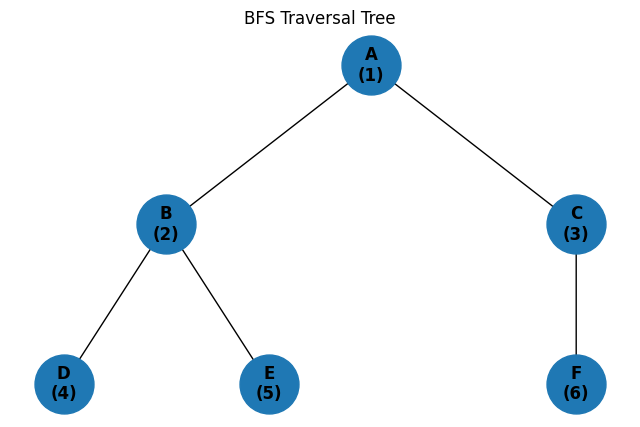

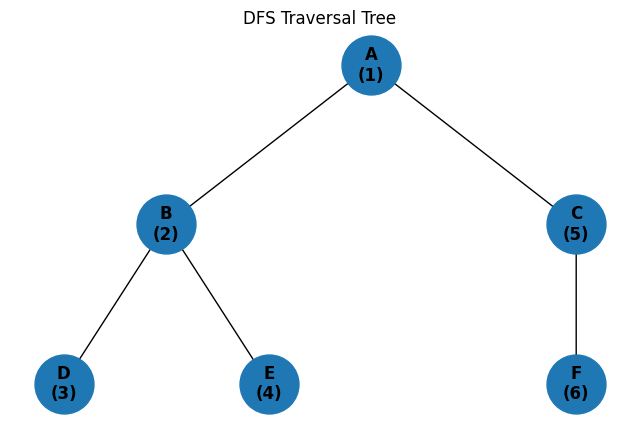

In [2]:
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx

# 1. Store the graph using an adjacency list
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}


# 2. BFS Traversal
def bfs(graph, start):
    visited = []
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.append(node)
            queue.extend(graph[node])

    return visited


# 3. DFS Traversal
def dfs(graph, start, visited=None):
    if visited is None:
        visited = []

    visited.append(start)

    for node in graph[start]:
        if node not in visited:
            dfs(graph, node, visited)

    return visited


# Perform traversals
bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')


# 4. Print traversal orders
print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))


# Function to draw traversal tree
def draw_tree(order, title):
    G = nx.DiGraph()

    # Original tree edges
    edges = [
        ('A', 'B'),
        ('A', 'C'),
        ('B', 'D'),
        ('B', 'E'),
        ('C', 'F')
    ]

    G.add_edges_from(edges)

    # Positions of nodes
    pos = {
        'A': (0, 2),
        'B': (-1, 1),
        'C': (1, 1),
        'D': (-1.5, 0),
        'E': (-0.5, 0),
        'F': (1, 0)
    }

    plt.figure(figsize=(8, 5))

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrows=True)

    # Draw nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1800
    )

    # Display node with visit order
    labels = {
        node: f"{node}\n({order.index(node) + 1})"
        for node in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=12,
        font_weight='bold'
    )

    plt.title(title)
    plt.axis('off')
    plt.show()


# Draw BFS tree
draw_tree(bfs_order, "BFS Traversal Tree")

# Draw DFS tree
draw_tree(dfs_order, "DFS Traversal Tree")

In [3]:
from collections import deque

# Jug capacities
JUG_A = 4
JUG_B = 3

# Goal: exactly 2 litres in either jug
def is_goal(state):
    a, b = state
    return a == 2 or b == 2


# Generate all possible next states
def get_next_states(state):
    a, b = state
    next_states = []

    # 1. Fill Jug A completely
    next_states.append(((JUG_A, b), "Fill Jug A"))

    # 2. Fill Jug B completely
    next_states.append(((a, JUG_B), "Fill Jug B"))

    # 3. Empty Jug A
    next_states.append(((0, b), "Empty Jug A"))

    # 4. Empty Jug B
    next_states.append(((a, 0), "Empty Jug B"))

    # 5. Pour A -> B
    pour = min(a, JUG_B - b)
    next_states.append(((a - pour, b + pour), "Pour A into B"))

    # 6. Pour B -> A
    pour = min(b, JUG_A - a)
    next_states.append(((a + pour, b - pour), "Pour B into A"))

    return next_states


# BFS function
def bfs_water_jug():
    start = (0, 0)

    # Each queue item contains:
    # (current_state, path_taken)
    queue = deque([(start, [])])

    visited = {start}

    while queue:
        state, path = queue.popleft()

        if is_goal(state):
            return state, path

        for next_state, operation in get_next_states(state):
            if next_state not in visited:
                visited.add(next_state)

                new_path = path + [(operation, next_state)]
                queue.append((next_state, new_path))

    return None, None


# Solve the problem
goal_state, solution = bfs_water_jug()

print("Initial State: (0, 0)")
print("Jug A capacity = 4 litres")
print("Jug B capacity = 3 litres")

if solution:
    print("\nMinimum sequence of steps:")

    for i, (operation, state) in enumerate(solution, start=1):
        print(f"Step {i}: {operation}")
        print(f"        State = {state}")

    print("\nGoal reached:", goal_state)
    print("Number of steps:", len(solution))
else:
    print("No solution found.")

Initial State: (0, 0)
Jug A capacity = 4 litres
Jug B capacity = 3 litres

Minimum sequence of steps:
Step 1: Fill Jug B
        State = (0, 3)
Step 2: Pour B into A
        State = (3, 0)
Step 3: Fill Jug B
        State = (3, 3)
Step 4: Pour B into A
        State = (4, 2)

Goal reached: (4, 2)
Number of steps: 4


In [4]:
# Graph representing the road network
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D'],
    'C': ['A'],
    'D': ['B'],
    'E': ['F'],
    'F': ['E'],
    'G': []
}


# Function to check whether a route exists
def route_exists(graph, start, destination, visited=None):
    if visited is None:
        visited = set()

    # If we reached the destination
    if start == destination:
        return True

    visited.add(start)

    # Visit all connected cities
    for city in graph[start]:
        if city not in visited:
            if route_exists(graph, city, destination, visited):
                return True

    return False


# Function to find one connected component using DFS
def dfs(graph, city, visited, component):
    visited.add(city)
    component.append(city)

    for neighbour in graph[city]:
        if neighbour not in visited:
            dfs(graph, neighbour, visited, component)


# Function to find all connected components
def find_connected_components(graph):
    visited = set()
    components = []

    for city in graph:
        if city not in visited:
            component = []
            dfs(graph, city, visited, component)
            components.append(component)

    return components


# -------------------------------
# Check whether routes exist
# -------------------------------

start_city = 'A'
destination_city = 'D'

if route_exists(graph, start_city, destination_city):
    print(f"Route exists from {start_city} to {destination_city}.")
else:
    print(f"No route exists from {start_city} to {destination_city}.")


# -------------------------------
# Find connected components
# -------------------------------

components = find_connected_components(graph)

print("\nConnected Components:")

for i, component in enumerate(components, start=1):
    print(f"Component {i}: {component}")

Route exists from A to D.

Connected Components:
Component 1: ['A', 'B', 'D', 'C']
Component 2: ['E', 'F']
Component 3: ['G']
